# Unsupervised – Vectorization & clustering (patient testimonies)

This notebook builds and compares **unsupervised clustering pipelines** for the CVRIE testimonies dataset.

## Subject compliance reminders
- We do **not** add labels.
- We do **not** use the hidden `color` field for training.
- We use `color` **only** to color plots for the defense requirement.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Same extended English stop list as in 01_data_cleaning_eda (sklearn list + short-text fillers)
_EXTRA_STOPS = frozenset({"just", "really", "quite", "also", "though", "maybe", "somewhat", "bit", "even", "still"})
STOP_WORDS = sorted(frozenset(ENGLISH_STOP_WORDS) | _EXTRA_STOPS)

TEST_SIZE = 0.2
RNG = 42

plt.style.use("seaborn-v0_8")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def save_current_fig(filename: str) -> None:
    path = FIG_DIR / filename
    plt.gcf().savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")

CLEAN_PATH = Path("cleaned_unsupervised_dataset.csv")
# Robust CSV parsing (the testimonies may contain commas/quotes)
df = pd.read_csv(
    CLEAN_PATH,
    engine="python",
    quotechar='"',
    escapechar="\\",
    skipinitialspace=True,
)
df.shape, df.columns.tolist()


((993, 4), ['id', 'color', 'testimony_raw', 'testimony_clean'])

In [2]:
df.head()


,id,color,testimony_raw,testimony_clean
0,2,0x000000,"The feverish feeling eased, but I’m now breath...",the feverish feeling eased but i'm now breathi...
1,3,0x000000,"While working in the garden, I touched a metal...",while working in the garden i touched a metal ...
2,4,NaN,A short sprint brought on a twinge in the midd...,a short sprint brought on a twinge in the midd...
3,5,0x000000,I accidentally left my hand on a hot mug for a...,i accidentally left my hand on a hot mug for a...
4,6,NaN,A sudden twist while reaching for a bag made o...,a sudden twist while reaching for a bag made o...


## 1) Vectorization baselines

We compare feature extraction approaches using only sklearn tools (per subject constraints):
- **TF-IDF (uni+bi-grams)**: strong bag-of-words baseline for short medical-like narratives.
- **TF-IDF → TruncatedSVD (LSA) → normalization**: reduces sparsity/noise and makes clustering distances more stable.

### Train / test split (no leakage)

We hold out **20%** of rows (`train_test_split`, fixed seed). **TF-IDF vocabulary and LSA (SVD) are fit only on the training texts**, then we **transform the full dataset** to assign clusters to everyone. That way, IDF statistics and latent directions are not fit on the held-out portion, while we still export one cluster per testimony.

### Stop words

We use `sklearn.feature_extraction.text.ENGLISH_STOP_WORDS` plus a small set of frequent narrative fillers (see notebook 01). Cleaning removes punctuation so tokens align with this list.

### Word2Vec / dense word embeddings

**Word2Vec** learns continuous word vectors from co-occurrence (a different paradigm from TF-IDF). Under the project tool constraint (scikit-learn, pandas, numpy, matplotlib), we **do not** train Word2Vec here; TF-IDF + LSA is the defendable analogue (sparse counts → low-dimensional dense space). External libraries such as Gensim would be needed for Word2Vec itself.


In [3]:
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(idx, test_size=TEST_SIZE, random_state=RNG)
texts_train = df.iloc[train_idx]["testimony_clean"].astype(str).tolist()
texts_all = df["testimony_clean"].astype(str).tolist()

tfidf = TfidfVectorizer(
    stop_words=STOP_WORDS,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
)
tfidf.fit(texts_train)
X_tfidf = tfidf.transform(texts_all)

print(f"rows={len(df)} | train={len(train_idx)} test={len(test_idx)} | tfidf {X_tfidf.shape}")
X_tfidf.shape


rows=993 | train=794 test=199 | tfidf (993, 2318)


(993, 2318)

Saved: figures/lsa_cumulative_variance.png


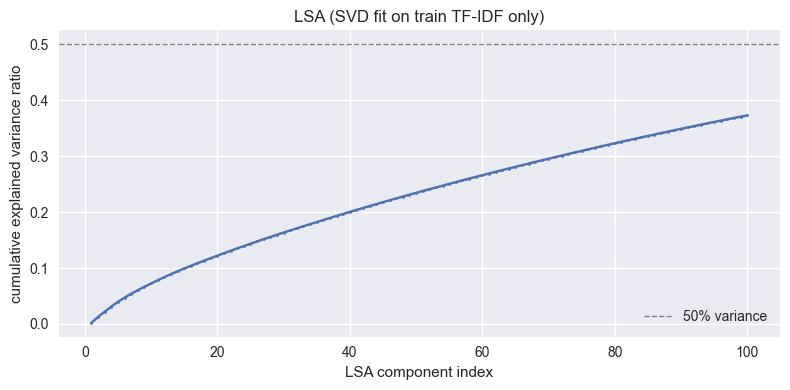

(993, 100)

In [4]:
SVD_DIMS = 100
lsa = make_pipeline(
    TruncatedSVD(n_components=SVD_DIMS, random_state=42),
    Normalizer(copy=False),
)
X_tfidf_train = tfidf.transform(texts_train)
lsa.fit(X_tfidf_train)
X_lsa = lsa.transform(X_tfidf)

svd = lsa.named_steps["truncatedsvd"]
cumvar = np.cumsum(svd.explained_variance_ratio_)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(np.arange(1, len(cumvar) + 1), cumvar, color="#4C72B0", marker=".", markersize=4)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="50% variance")
ax.set_xlabel("LSA component index")
ax.set_ylabel("cumulative explained variance ratio")
ax.set_title("LSA (SVD fit on train TF-IDF only)")
ax.legend(loc="lower right")
plt.tight_layout()
save_current_fig("lsa_cumulative_variance.png")
plt.show()

X_lsa.shape


## 2) Clustering baselines

We try multiple clustering families (as required):
- **KMeans** (often strong for TF-IDF/LSA text features)
- **Agglomerative** (average linkage; applied on LSA features)
- **DBSCAN** (density-based; applied on LSA features)

Because we have no labels, we compare using multiple **unsupervised metrics** and qualitative inspection.


### Loss / objective (subject requirement)

Even in unsupervised learning, our model optimizes an objective.

- **KMeans “loss”**: it minimizes **inertia**, the sum of squared distances from each point to its assigned centroid:

  \[
  inertia = np.sum([np.linalg.norm(x[i] - mu[c[i]])**2 for i in range(len(x))])
  \]

  where \(x[i]\) is a sample (here: an LSA vector), \(c[i]\) is its cluster assignment, and \(mu\) are the centroids.

- **Why we use TF‑IDF → LSA before KMeans**: TF‑IDF is high-dimensional and sparse; LSA (TruncatedSVD + normalization) produces a dense representation where Euclidean distances are more stable, making KMeans optimization and comparisons more meaningful.

- **We do not use hidden `color` for training**: it is only used to color plots for the defense.


In [ ]:
@dataclass
class RunResult:
    name: str
    n_clusters: int
    noise_rate: float
    silhouette: float | None
    calinski_harabasz: float | None
    davies_bouldin: float | None
    top_cluster_sizes: list[int]


def _cluster_sizes(labels: np.ndarray) -> list[int]:
    valid = labels[labels >= 0]
    if valid.size == 0:
        return []
    return sorted(np.bincount(valid).tolist(), reverse=True)


def evaluate_unsupervised(
    X: Any,
    labels: np.ndarray,
    *,
    silhouette_metric: str,
) -> tuple[float | None, float | None, float | None]:
    unique = sorted(set(int(x) for x in labels.tolist() if int(x) != -1))
    if len(unique) < 2:
        return None, None, None

    sample_size = min(600, len(labels))
    sil = silhouette_score(
        X,
        labels,
        metric=silhouette_metric,
        sample_size=sample_size,
        random_state=42,
    )

    # CH/DB require a dense numeric array. For sparse TF-IDF matrices, we skip them
    # and rely on silhouette + the dense LSA runs for CH/DB comparisons.
    is_sparse = hasattr(X, "toarray") and not isinstance(X, np.ndarray)
    if is_sparse:
        return float(sil), None, None

    X_dense = np.asarray(X)
    ch = calinski_harabasz_score(X_dense, labels)
    db = davies_bouldin_score(X_dense, labels)
    return float(sil), float(ch), float(db)


def run_and_score(name: str, model: Any, X: Any, *, silhouette_metric: str) -> RunResult:
    labels = np.asarray(model.fit_predict(X))
    unique_all = sorted(set(int(x) for x in labels.tolist()))
    n_clusters = len([u for u in unique_all if u != -1])
    noise_rate = float(np.mean(labels == -1))
    sil, ch, db = evaluate_unsupervised(X, labels, silhouette_metric=silhouette_metric)

    return RunResult(
        name=name,
        n_clusters=n_clusters,
        noise_rate=noise_rate,
        silhouette=sil,
        calinski_harabasz=ch,
        davies_bouldin=db,
        top_cluster_sizes=_cluster_sizes(labels)[:10],
    )


def results_to_df(results: list[RunResult]) -> pd.DataFrame:
    return pd.DataFrame([r.__dict__ for r in results])


## 3) Model comparisons (parameter sweeps)

We keep the sweeps small and readable for a defense presentation.


Saved: figures/kmeans_lsa_silhouette_vs_k.png


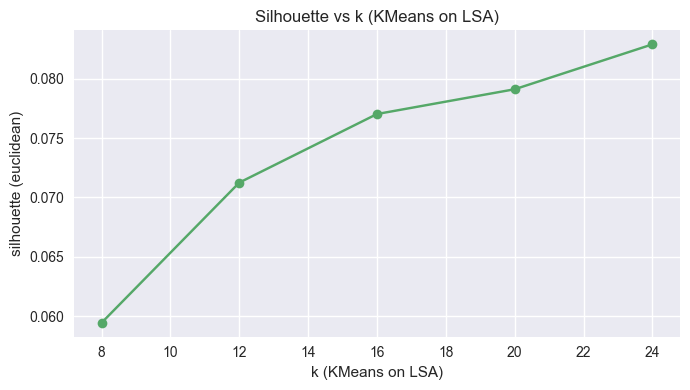

,name,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin,top_cluster_sizes
9,kmeans_lsa24,24,0.0,0.082900,14.141722,3.063446,"[76, 65, 64, 57, 56, 54, 52, 49, 45, 42]"
8,kmeans_lsa20,20,0.0,0.079118,15.136237,3.180697,"[89, 87, 75, 68, 65, 65, 60, 57, 53, 53]"
7,kmeans_lsa16,16,0.0,0.077030,16.762138,3.366016,"[106, 86, 82, 81, 71, 67, 67, 66, 60, 55]"
6,kmeans_lsa12,12,0.0,0.071254,18.356059,3.701946,"[184, 98, 95, 88, 85, 83, 73, 66, 60, 60]"
5,kmeans_lsa8,8,0.0,0.059446,20.707969,4.017398,"[165, 161, 147, 133, 125, 89, 89, 84]"
13,agglo_lsa20,20,0.0,0.058968,12.738791,3.044816,"[105, 98, 76, 69, 67, 66, 64, 64, 60, 60]"
12,agglo_lsa16,16,0.0,0.048829,12.841852,3.267979,"[136, 124, 113, 105, 98, 69, 67, 64, 60, 47]"
11,agglo_lsa12,12,0.0,0.045257,14.611862,3.596453,"[167, 124, 124, 116, 113, 98, 67, 64, 60, 28]"
10,agglo_lsa8,8,0.0,0.039132,15.744546,3.823211,"[308, 212, 124, 116, 98, 67, 64, 4]"
4,kmeans_tfidf_k24,24,0.0,0.032450,NaN,NaN,"[120, 71, 63, 58, 54, 48, 48, 41, 40, 38]"


In [6]:
results: list[RunResult] = []

# KMeans on TF-IDF (sparse)
for k in [8, 12, 16, 20, 24]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    results.append(run_and_score(f"kmeans_tfidf_k{k}", km, X_tfidf, silhouette_metric="cosine"))

# KMeans on LSA (dense)
for k in [8, 12, 16, 20, 24]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    results.append(run_and_score(f"kmeans_lsa{k}", km, X_lsa, silhouette_metric="euclidean"))

# Agglomerative on LSA
for k in [8, 12, 16, 20]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="average", metric="euclidean")
    results.append(run_and_score(f"agglo_lsa{k}", agg, X_lsa, silhouette_metric="euclidean"))

# DBSCAN on LSA
for eps in [0.30, 0.35, 0.40]:
    for min_s in [5, 10]:
        dbs = DBSCAN(eps=eps, min_samples=min_s, metric="euclidean")
        results.append(run_and_score(f"dbscan_lsa_eps{eps}_min{min_s}", dbs, X_lsa, silhouette_metric="euclidean"))

res_df = results_to_df(results)
display_top = res_df.sort_values(["silhouette"], ascending=False).head(10)

_km_lsa = res_df[res_df["name"].str.startswith("kmeans_lsa")].copy()
_km_lsa["k"] = _km_lsa["name"].str.replace("kmeans_lsa", "", regex=False).astype(int)
_km_lsa = _km_lsa.sort_values("k")
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(_km_lsa["k"], _km_lsa["silhouette"], marker="o", color="#55A868")
ax.set_xlabel("k (KMeans on LSA)")
ax.set_ylabel("silhouette (euclidean)")
ax.set_title("Silhouette vs k (KMeans on LSA)")
plt.tight_layout()
save_current_fig("kmeans_lsa_silhouette_vs_k.png")
plt.show()

display_top


Saved: figures/model_top_silhouette.png


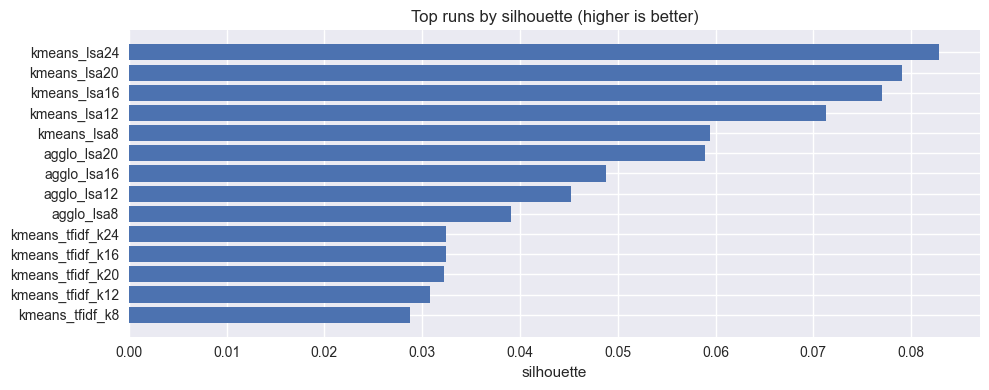

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
tmp = res_df.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).head(15)
ax.barh(tmp["name"], tmp["silhouette"], color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Top runs by silhouette (higher is better)")
ax.set_xlabel("silhouette")
plt.tight_layout()
save_current_fig("model_top_silhouette.png")
plt.show()


## 4) Choose a candidate model

We pick a candidate run combining metrics + cluster size balance + interpretability.
As a defendable baseline, we pick the best silhouette among KMeans/LSA runs.


In [8]:
best_row = (
    res_df[res_df["name"].str.startswith("kmeans_lsa")]
    .sort_values("silhouette", ascending=False)
    .iloc[0]
)
best_row


name                                             kmeans_lsa24
n_clusters                                                 24
noise_rate                                                0.0
silhouette                                             0.0829
calinski_harabasz                                   14.141722
davies_bouldin                                       3.063446
top_cluster_sizes    [76, 65, 64, 57, 56, 54, 52, 49, 45, 42]
Name: 9, dtype: object

In [9]:
best_name = str(best_row["name"])
best_k = int(best_name.replace("kmeans_lsa", ""))
best_model = KMeans(n_clusters=best_k, n_init=20, random_state=42)
best_labels = best_model.fit_predict(X_lsa)
best_labels[:10], best_k


(array([ 6,  1,  2,  7,  4,  7,  9, 17,  9, 17], dtype=int32), 24)

### Cluster size balance


In [10]:
sizes = pd.Series(best_labels).value_counts().sort_index()
sizes


0     26
1     36
2     56
3     21
4     38
5     52
6     34
7     29
8     49
9     64
10    76
11    57
12    65
13    54
14    45
15    14
16    30
17    37
18    19
19    41
20    39
21    41
22    28
23    42
Name: count, dtype: int64

Saved: figures/model_cluster_sizes.png


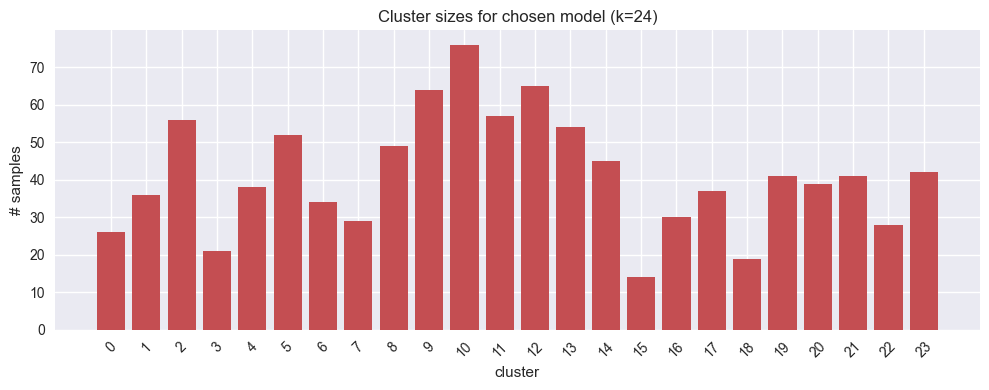

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(sizes.index.astype(str), sizes.values, color="#C44E52")
ax.set_title(f"Cluster sizes for chosen model (k={best_k})")
ax.set_xlabel("cluster")
ax.set_ylabel("# samples")
plt.xticks(rotation=45)
plt.tight_layout()
save_current_fig("model_cluster_sizes.png")
plt.show()


## 5) Interpretability: top terms and representative examples

We extract:
- top TF-IDF terms per cluster (for naming/intuition)
- a few representative testimonies per cluster (closest to centroid)


In [12]:
km_tfidf = KMeans(n_clusters=best_k, n_init=20, random_state=42)
labels_tfidf = km_tfidf.fit_predict(X_tfidf)

feature_names = np.array(tfidf.get_feature_names_out())
top_n = 10

top_terms = {}
for c in range(best_k):
    centroid = km_tfidf.cluster_centers_[c]
    top_idx = np.argsort(centroid)[::-1][:top_n]
    top_terms[c] = feature_names[top_idx].tolist()

pd.DataFrame({"cluster": list(top_terms.keys()), "top_terms": list(top_terms.values())}).head()


,cluster,top_terms
0,0,"[felt, throat, low, sore, fever, felt sore, gr..."
1,1,"[cough, chest, short, chest feels, feels, tigh..."
2,2,"[ear, pain, ear hurts, pain ear, hurts, sound,..."
3,3,"[forearm, finger, little, little finger, palm,..."
4,4,"[make, ache, leg, crossing, ankle, deep, thigh..."


In [13]:
df_out = df[["id", "color", "testimony_raw", "testimony_clean"]].copy()
df_out["cluster"] = best_labels

centroids_lsa = np.vstack([X_lsa[best_labels == c].mean(axis=0) for c in range(best_k)])

def closest_examples(cluster_id: int, n: int = 3) -> pd.DataFrame:
    idx = np.where(best_labels == cluster_id)[0]
    if idx.size == 0:
        return df_out.iloc[0:0]
    pts = X_lsa[idx]
    c = centroids_lsa[cluster_id]
    dists = np.linalg.norm(pts - c, axis=1)
    pick = idx[np.argsort(dists)[:n]]
    return df_out.loc[pick, ["id", "testimony_raw"]]

for c in range(min(5, best_k)):
    print(f"Cluster {c} top terms: {top_terms.get(c, [])}")
    display(closest_examples(c, n=3))


Cluster 0 top terms: ['felt', 'throat', 'low', 'sore', 'fever', 'felt sore', 'grade', 'low grade', 'grade fever', 'sore throat']


,id,testimony_raw
263,265,"I feel a sore throat, a clear nasal drip, and ..."
299,301,I had a low fever and a sore throat that began...
475,481,I felt a tickle in my throat and started sneez...


Cluster 1 top terms: ['cough', 'chest', 'short', 'chest feels', 'feels', 'tight', 'breath', 'walk', 'like', 'night']


,id,testimony_raw
313,315,"While fixing the faucet, a hot pipe touched my..."
410,414,I used a hair straightener that was too hot an...
73,75,I left a cup of hot cocoa on my desk and touch...


Cluster 2 top terms: ['ear', 'pain', 'ear hurts', 'pain ear', 'hurts', 'sound', 'hear', 'feel', 'ear feels', 'left ear']


,id,testimony_raw
247,249,"After a few days of high aches and chills, I d..."
561,568,Mornings start with several coughs to clear th...
715,726,"A deep, dry cough leaves me short of breath af..."


Cluster 3 top terms: ['forearm', 'finger', 'little', 'little finger', 'palm', 'sore', 'stings', 'twisting', 'sting', 'pan']


,id,testimony_raw
235,237,"I keep feeling lightheaded, and my skin is pal..."
537,544,I feel faint and my skin turns pale when I sta...
816,830,My heart races and I get shortness of breath e...


Cluster 4 top terms: ['make', 'ache', 'leg', 'crossing', 'ankle', 'deep', 'thigh', 'hip', 'inner', 'groin']


,id,testimony_raw
976,995,"After throwing a ball, the back‑outer shoulder..."
716,727,Taking a deep breath gives a thin ache between...
412,416,Putting on a jacket makes the front of my shou...


## 6) Required plots: clusters vs hidden `color`

We project the TF-IDF space into 2D using SVD and plot:
- points colored by **cluster**
- points colored by hidden **color** (viz-only)


Saved: figures/2d_projection_colored_by_cluster_k24.png


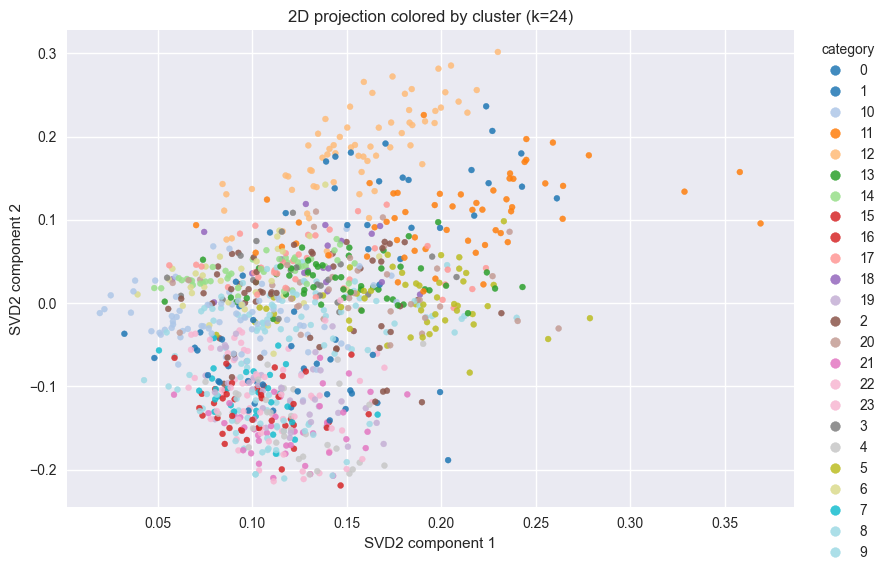

Saved: figures/2d_projection_colored_by_hidden_color_viz_only.png


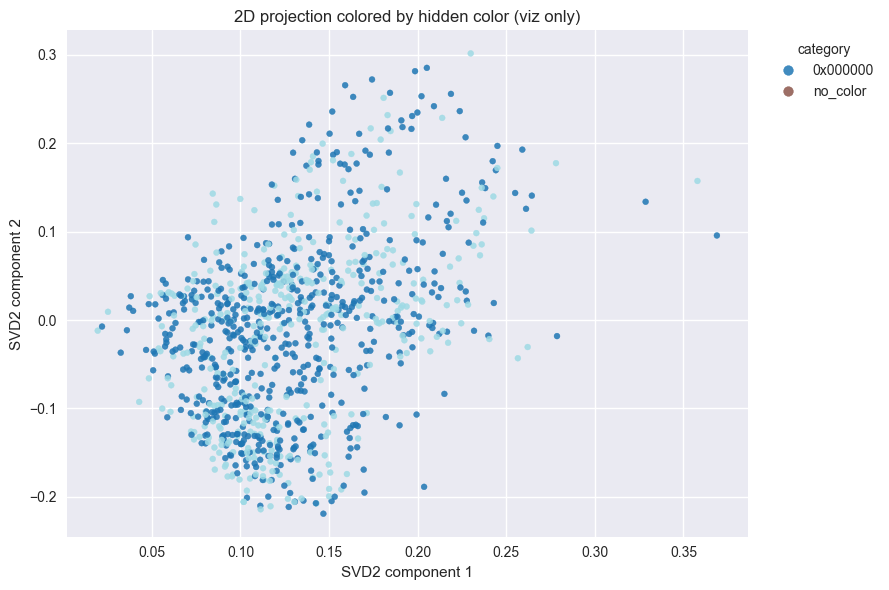

In [14]:
svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X_tfidf)

def scatter_by(values, title: str, *, s: int = 18):
    fig, ax = plt.subplots(1, 1, figsize=(9, 6))
    vals = pd.Series(values).astype(str).fillna("None")
    uniq = vals.nunique()

    if uniq <= 25:
        cats = vals.astype("category")
        sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=cats.cat.codes, cmap="tab20", s=s, alpha=0.85)
        handles, _ = sc.legend_elements(num=min(uniq, 20))
        ax.legend(handles, list(cats.cat.categories)[: len(handles)], title="category", bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        codes = vals.astype("category").cat.codes
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=codes, cmap="viridis", s=s, alpha=0.85)

    ax.set_title(title)
    ax.set_xlabel("SVD2 component 1")
    ax.set_ylabel("SVD2 component 2")
    plt.tight_layout()
    # Save a stable filename derived from the title
    safe = (
        title.lower()
        .replace(" ", "_")
        .replace("=", "")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
    )
    save_current_fig(f"{safe}.png")
    plt.show()

scatter_by(best_labels, f"2D projection colored by cluster (k={best_k})")
scatter_by(df_out["color"].fillna("no_color"), "2D projection colored by hidden color (viz only)")


## 7) Save clustering output

We export a file for later use / defense: `id`, `cluster`, `color` (viz-only), and `testimony_raw`.


In [15]:
CLUSTERS_PATH = Path("unsupervised_clusters.csv")
df_save = df_out[["id", "cluster", "color", "testimony_raw"]].copy()
df_save.to_csv(CLUSTERS_PATH, index=False)
CLUSTERS_PATH.resolve()


PosixPath('/Users/karma/code/epitech/2_year/G-AIA-400-LYN-4-1-cvrie-3/unsupervised/unsupervised_clusters.csv')